# Bloch Walk Process (TomQA) Demonstration

This notebook demonstrates the **Bloch walk** (also called TomQA) - a 3-state, 4-emission quantum process that models quantum walks on the Bloch sphere.

Key features:
- **4 emissions** (0, 1, 2, 3) corresponding to different quantum measurement outcomes
- **3 hidden states**
- **Parameters**: `alpha` and `beta` control the quantum walk dynamics
- **Quantum process**: Transition matrices contain **negative values** representing quantum interference
- Related to quantum measurement and Bloch sphere geometry

**Important:** Unlike classical stochastic processes (like Mess3), quantum processes cannot be directly sampled from transition matrices. We use the GHMM library's belief state propagation to properly handle quantum dynamics.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Add epsilon_transformers to path
project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from epsilon_transformers.process.transition_matrices import tom_quantum
from epsilon_transformers.process.GHMM import TransitionMatrixGHMM

print("Imports successful!")

Imports successful!


## 1. Generate the Bloch Walk Transition Tensor

The transition tensor has shape `(4, 3, 3)` representing `[emission, from_state, to_state]`.

In [2]:
# Generate the Bloch walk process with typical parameters
alpha = 1.0
beta = 0.5
T_bloch = tom_quantum(alpha=alpha, beta=beta)

print(f"Bloch walk transition tensor shape: {T_bloch.shape}")
print(f"Parameters: alpha={alpha}, beta={beta}")
print(f"\nNumber of emissions: {T_bloch.shape[0]}")
print(f"Number of states: {T_bloch.shape[1]}")

# Calculate derived parameter
gamma = 1/(2*np.sqrt(alpha**2 + beta**2))
print(f"\nDerived parameter gamma: {gamma:.4f}")

# Print all 4 emission matrices
for i in range(4):
    print(f"\nT[{i}] (Emission {i}):\n{T_bloch[i]}")

Bloch walk transition tensor shape: (4, 3, 3)
Parameters: alpha=1.0, beta=0.5

Number of emissions: 4
Number of states: 3

Derived parameter gamma: 0.4472

T[0] (Emission 0):
[[0.25 0.   0.2 ]
 [0.   0.15 0.  ]
 [0.2  0.   0.25]]

T[1] (Emission 1):
[[ 0.25  0.   -0.2 ]
 [ 0.    0.15  0.  ]
 [-0.2   0.    0.25]]

T[2] (Emission 2):
[[0.25 0.2  0.  ]
 [0.2  0.25 0.  ]
 [0.   0.   0.15]]

T[3] (Emission 3):
[[ 0.25 -0.2   0.  ]
 [-0.2   0.25  0.  ]
 [ 0.    0.    0.15]]


## 2. Verify Normalization

Check that the process is properly normalized. 

**Note:** Quantum processes are NOT classically stochastic (they have negative entries). The normalization condition is that the sum of all emission matrices has row sums equal to 1, but individual matrices can have negative values.

In [3]:
# Sum over all emissions
T_sum = T_bloch.sum(axis=0)

print("Sum of all emission matrices:")
print(T_sum)
print("\nRow sums (should all be ~1.0):")
print(T_sum.sum(axis=1))

# Verify normalization
is_normalized = np.allclose(T_sum.sum(axis=1), 1.0)
print(f"\nIs properly normalized: {is_normalized}")

# Check for negative values (expected in quantum processes)
has_negative_values = (T_bloch < 0).any()
print(f"Contains negative values (quantum interference): {has_negative_values}")
print(f"Minimum value: {T_bloch.min():.4f}")
print(f"Maximum value: {T_bloch.max():.4f}")

Sum of all emission matrices:
[[1.  0.  0. ]
 [0.  0.8 0. ]
 [0.  0.  0.8]]

Row sums (should all be ~1.0):
[1.  0.8 0.8]

Is properly normalized: False
Contains negative values (quantum interference): True
Minimum value: -0.2000
Maximum value: 0.2500


## 3. Visualize Bloch Walk Transition Matrices

The Bloch walk has 4 emission matrices corresponding to different quantum measurement outcomes.

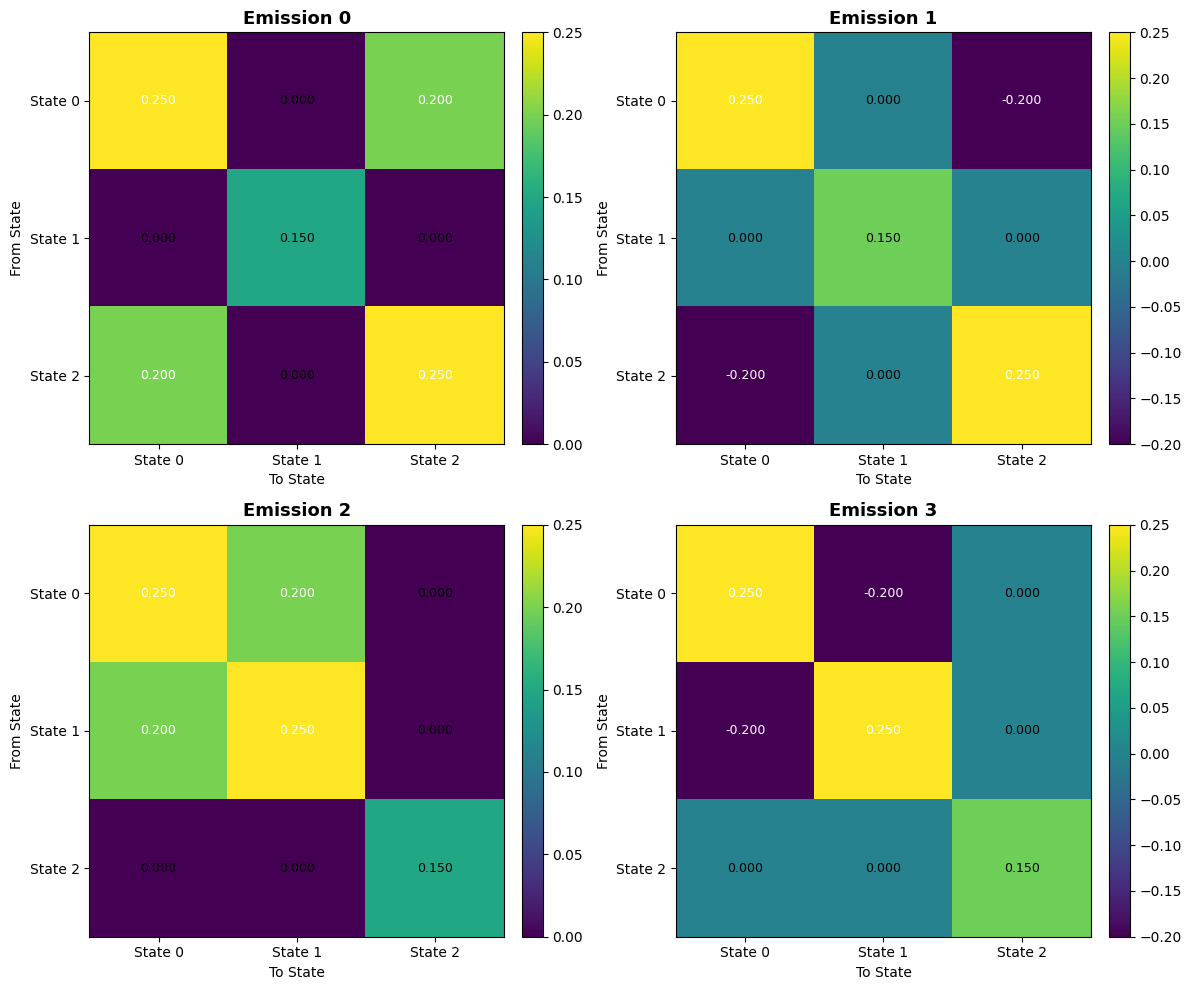

Bloch walk transition matrices saved as 'bloch_walk_transition_matrices.png'


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

emission_labels = ['Emission 0', 'Emission 1', 'Emission 2', 'Emission 3']
state_labels = ['State 0', 'State 1', 'State 2']

for i, (ax, label) in enumerate(zip(axes, emission_labels)):
    im = ax.imshow(T_bloch[i], cmap='viridis', aspect='auto')
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('To State', fontsize=10)
    ax.set_ylabel('From State', fontsize=10)
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(state_labels)
    ax.set_yticklabels(state_labels)
    
    # Add text annotations
    for row in range(3):
        for col in range(3):
            val = T_bloch[i, row, col]
            color = 'white' if abs(val) > 0.15 else 'black'
            text = ax.text(col, row, f'{val:.3f}',
                         ha="center", va="center", color=color, fontsize=9)
    
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('bloch_walk_transition_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("Bloch walk transition matrices saved as 'bloch_walk_transition_matrices.png'")

## 4. Simulate Bloch Walk Sequence

Generate a sequence from the Bloch walk process using the **GHMM library**.

**Note:** Quantum processes like Bloch Walk have **negative values** in their transition matrices, which represent quantum interference. We cannot directly sample from these matrices as probabilities. Instead, we use the GHMM's belief state propagation method which correctly handles the quantum dynamics.

In [11]:
def simulate_quantum_process(T, num_steps=10000, seed=42):
    """
    Simulate a sequence from a quantum process using GHMM library.
    
    This properly handles processes with negative transition matrix entries
    by using belief state propagation rather than direct sampling.
    
    Parameters:
    -----------
    T : np.ndarray
        Transition tensor of shape (n_emissions, n_states, n_states)
    num_steps : int
        Number of transitions to simulate
    seed : int
        Random seed for reproducibility
    
    Returns:
    --------
    emissions : list
        Sequence of emissions
    belief_states : list
        Sequence of belief states (probability distributions over hidden states)
    """
    np.random.seed(seed)
    
    # Wrap transition matrix in GHMM object
    ghmm = TransitionMatrixGHMM(T)
    
    # Track emissions and belief states
    emissions = []
    belief_states = []
    
    # Start from steady state
    latent_state = ghmm.steady_state_vector
    belief_states.append(latent_state.squeeze().copy())
    
    # Generate sequence
    for _ in range(num_steps):
        emission, next_latent = ghmm._sample_emission_and_next_latent(latent_state)
        emissions.append(emission)
        belief_states.append(next_latent.squeeze().copy())
        latent_state = next_latent
    
    return emissions, belief_states


# Simulate Bloch walk sequence using proper GHMM methods
emissions, belief_trajectory = simulate_quantum_process(T_bloch, num_steps=10000, seed=42)

print(f"Generated {len(emissions)} Bloch walk emissions")
print(f"\nFirst 20 emissions: {emissions[:20]}")
print(f"\nFirst 5 belief states:")
for i in range(min(5, len(belief_trajectory))):
    print(f"  t={i}: {belief_trajectory[i]}")
    
# Note: For visualization, we'll use belief states as a proxy for "states"
# since quantum processes don't have definite states, only belief distributions
states = [np.argmax(b) for b in belief_trajectory]  # Most likely state at each step
print(f"\nFirst 20 most-likely states: {states[:20]}")

Generated 10000 Bloch walk emissions

First 20 emissions: [1, 3, 3, 3, 0, 0, 0, 3, 3, 3, 0, 3, 3, 0, 0, 0, 0, 2, 1, 1]

First 5 belief states:
  t=0: [1. 0. 0.]
  t=1: [ 0.33333333  0.         -0.26666667]
  t=2: [ 0.33333333 -0.26666667 -0.16      ]
  t=3: [ 0.33333333 -0.32520325 -0.05853659]
  t=4: [ 0.33333333 -0.33242009 -0.01972603]

First 20 most-likely states: [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]


## 5. Visualize the Sequence

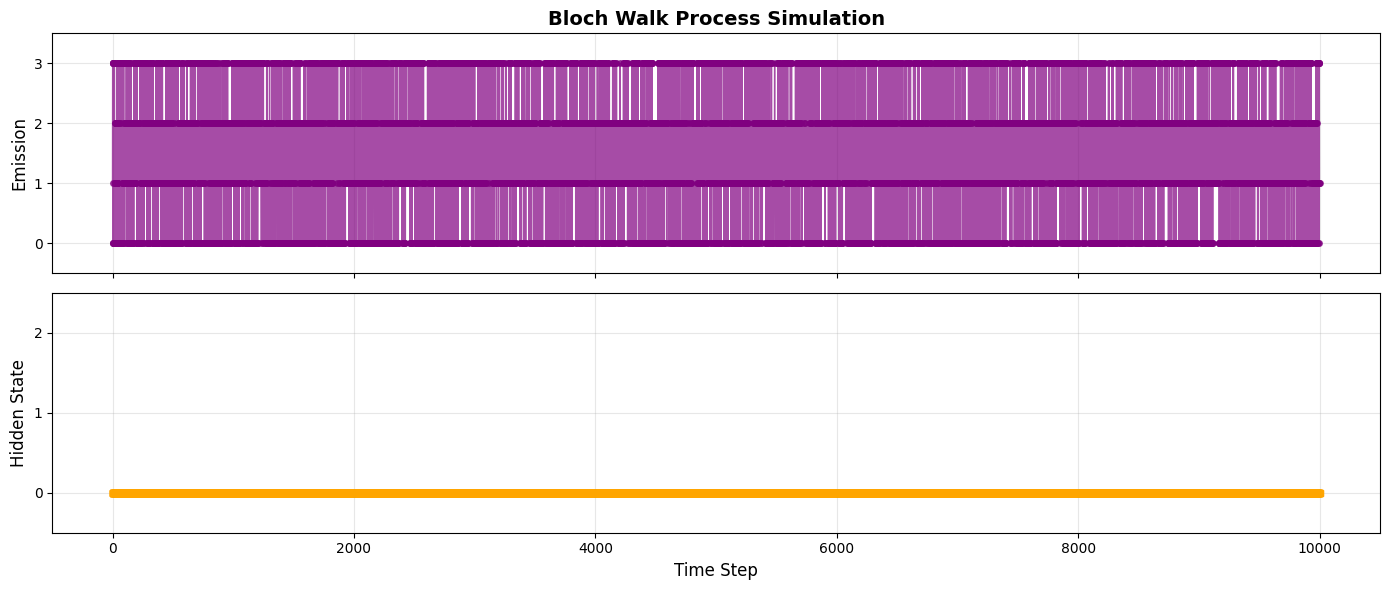

Sequence visualization saved as 'bloch_walk_sequence.png'


In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Plot emissions
ax1.plot(emissions, 'o-', markersize=4, linewidth=1, alpha=0.7, color='purple')
ax1.set_ylabel('Emission', fontsize=12)
ax1.set_yticks([0, 1, 2, 3])
ax1.set_title('Bloch Walk Process Simulation', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.5, 3.5)

# Plot states
ax2.plot(states, 's-', markersize=4, linewidth=1, alpha=0.7, color='orange')
ax2.set_xlabel('Time Step', fontsize=12)
ax2.set_ylabel('Hidden State', fontsize=12)
ax2.set_yticks([0, 1, 2])
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.5, 2.5)

plt.tight_layout()
plt.savefig('bloch_walk_sequence.png', dpi=150, bbox_inches='tight')
plt.show()

print("Sequence visualization saved as 'bloch_walk_sequence.png'")

## 6. Analyze Emission and State Distributions

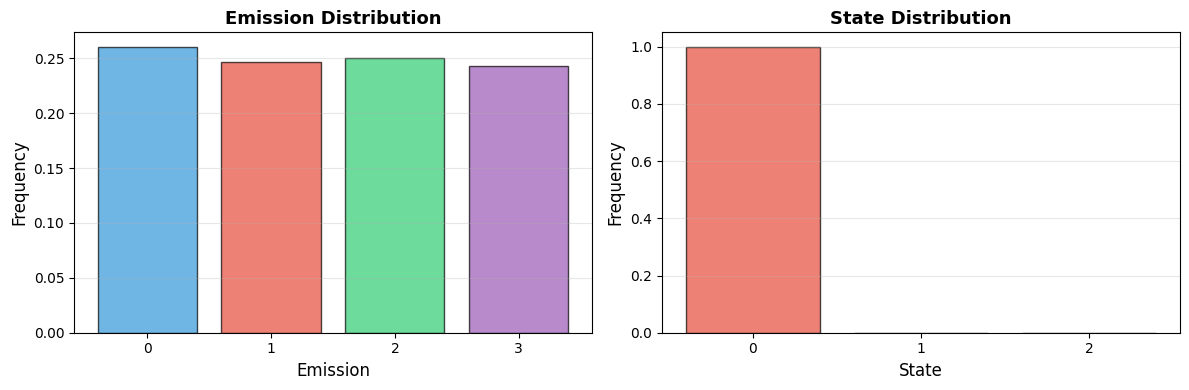


Emission frequencies: [0.2606 0.247  0.2498 0.2426]
State frequencies: [1. 0. 0.]


In [13]:
# Count frequencies
emission_counts = np.bincount(emissions, minlength=4)
state_counts = np.bincount(states, minlength=3)

# Normalize
emission_freqs = emission_counts / len(emissions)
state_freqs = state_counts / len(states)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Emission distribution
ax1.bar([0, 1, 2, 3], emission_freqs, 
        color=['#3498db', '#e74c3c', '#2ecc71', '#9b59b6'], alpha=0.7, edgecolor='black')
ax1.set_xlabel('Emission', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Emission Distribution', fontsize=13, fontweight='bold')
ax1.set_xticks([0, 1, 2, 3])
ax1.grid(axis='y', alpha=0.3)

# State distribution
ax2.bar([0, 1, 2], state_freqs, 
        color=['#e74c3c', '#3498db', '#2ecc71'], alpha=0.7, edgecolor='black')
ax2.set_xlabel('State', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('State Distribution', fontsize=13, fontweight='bold')
ax2.set_xticks([0, 1, 2])
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('bloch_walk_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nEmission frequencies:", emission_freqs)
print("State frequencies:", state_freqs)

## 7. Belief State Calculation

**Belief states** represent the probability distribution over hidden states given the observation history.

For the Bloch walk, we use Bayes filtering:
```
b_{t+1}(s') ∝ Σ_s T[o_t, s, s'] * b_t(s)
```

In [14]:
def compute_belief_states(T, emissions, initial_belief=None):
    """
    Compute belief states using Bayes filtering.
    
    Parameters:
    -----------
    T : np.ndarray
        Transition tensor of shape (n_emissions, n_states, n_states)
    emissions : list or np.ndarray
        Sequence of observed emissions
    initial_belief : np.ndarray, optional
        Initial belief distribution. If None, uses uniform distribution.
    
    Returns:
    --------
    beliefs : np.ndarray
        Array of belief states, shape (n_steps+1, n_states)
    """
    n_emissions, n_states, _ = T.shape
    
    # Initialize belief state
    if initial_belief is None:
        belief = np.ones(n_states) / n_states
    else:
        belief = np.array(initial_belief)
        belief = belief / belief.sum()
    
    # Store all belief states
    beliefs = [belief.copy()]
    
    for emission in emissions:
        # Get the transition matrix for this emission
        T_obs = T[emission]
        
        # Belief update
        new_belief = T_obs.T @ belief
        
        # Normalize
        new_belief = new_belief / new_belief.sum()
        
        beliefs.append(new_belief.copy())
        belief = new_belief
    
    return np.array(beliefs)


# Compute belief states for Bloch walk
beliefs = compute_belief_states(T_bloch, emissions, initial_belief=None)

print(f"Computed {len(beliefs)} belief states")
print(f"Belief shape: {beliefs.shape}")
print(f"\nInitial belief (uniform): {beliefs[0]}")
print(f"Final belief: {beliefs[-1]}")
print(f"\nFirst 5 beliefs:")
for i in range(min(5, len(beliefs))):
    print(f"  t={i}: {beliefs[i]}")

Computed 10001 belief states
Belief shape: (10001, 3)

Initial belief (uniform): [0.33333333 0.33333333 0.33333333]
Final belief: [-5.05521134  1.12729392  4.92791742]

First 5 beliefs:
  t=0: [0.33333333 0.33333333 0.33333333]
  t=1: [0.2 0.6 0.2]
  t=2: [-1.          1.57142857  0.42857143]
  t=3: [-6.07692308  6.38461538  0.69230769]
  t=4: [-23.4516129   23.58064516   0.87096774]


## 8. Visualize Belief State Evolution

Plot how the probability of each state changes over time.

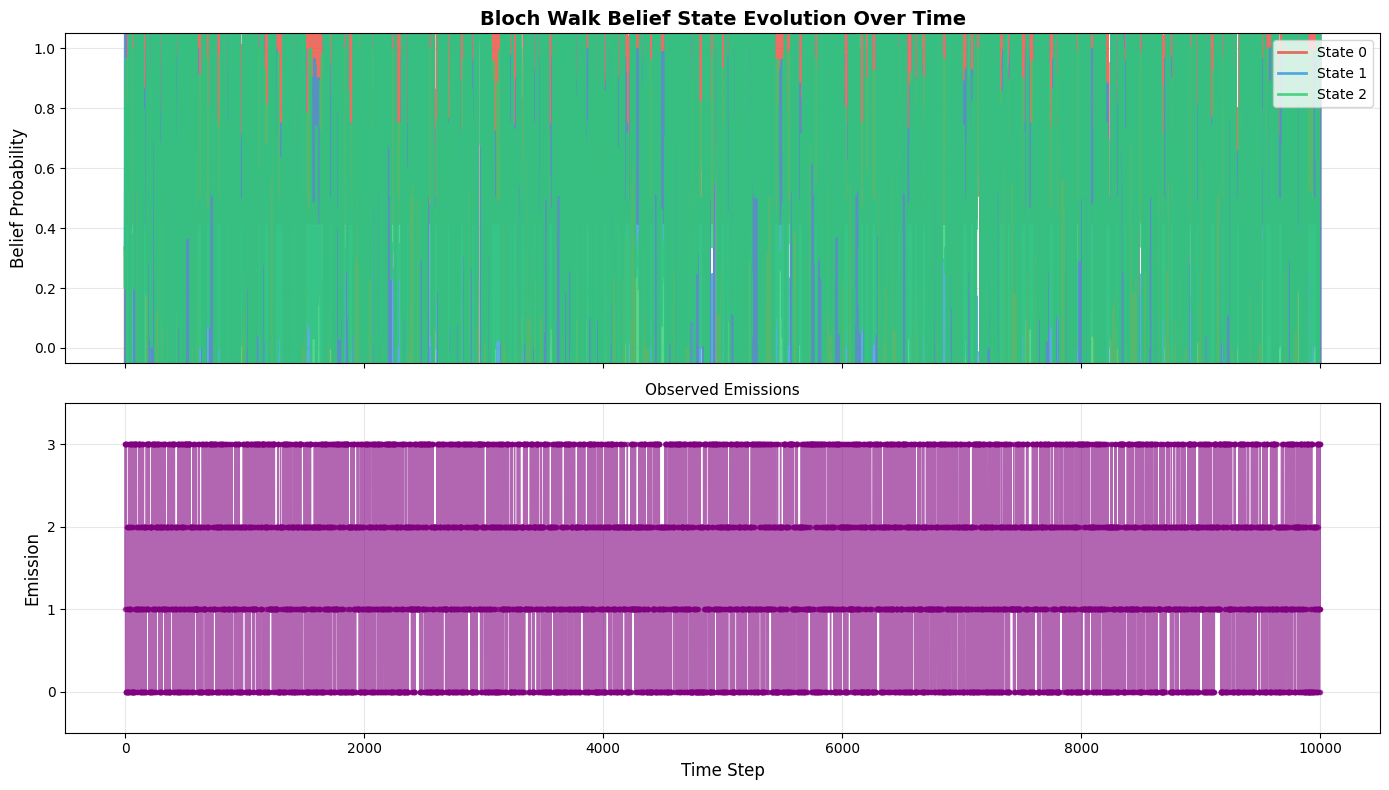

Belief state evolution saved as 'bloch_walk_belief_evolution.png'


In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

time_steps = np.arange(len(beliefs))
colors = ['#e74c3c', '#3498db', '#2ecc71']
state_labels = ['State 0', 'State 1', 'State 2']

# Top panel: Belief state evolution
for i in range(3):
    ax1.plot(time_steps, beliefs[:, i], label=state_labels[i], 
             color=colors[i], linewidth=2, alpha=0.8)

ax1.set_ylabel('Belief Probability', fontsize=12)
ax1.set_title('Bloch Walk Belief State Evolution Over Time', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.05, 1.05)

# Bottom panel: Emissions
ax2.plot(emissions, 'o-', markersize=3, linewidth=1, alpha=0.6, color='purple')
ax2.set_xlabel('Time Step', fontsize=12)
ax2.set_ylabel('Emission', fontsize=12)
ax2.set_yticks([0, 1, 2, 3])
ax2.set_title('Observed Emissions', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.5, 3.5)

plt.tight_layout()
plt.savefig('bloch_walk_belief_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Belief state evolution saved as 'bloch_walk_belief_evolution.png'")

## 9. Belief State Trajectory on Probability Simplex

Since belief states are probability distributions over 3 states, they lie on a 2-simplex (triangle).

/tmp/ipykernel_2313034/2959368477.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=11)


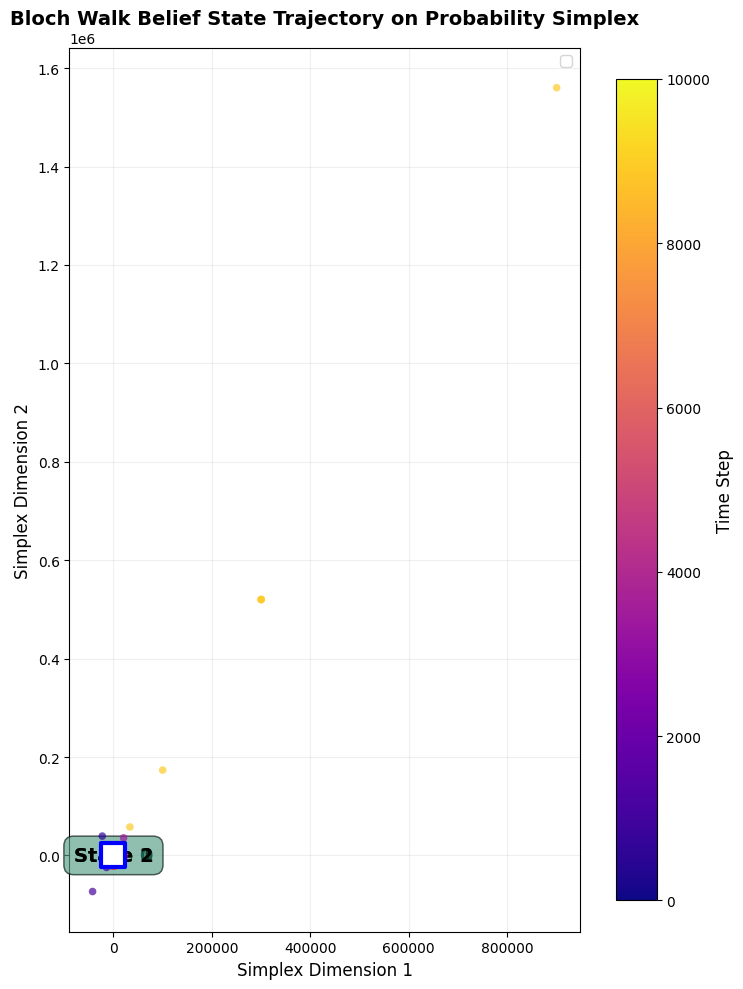

Belief simplex trajectory saved as 'bloch_walk_belief_simplex.png'


In [ ]:
def project_to_simplex_2d(beliefs):
    """
    Project 3D probability simplex to 2D coordinates for visualization.
    """
    # Project to 2D equilateral triangle
    x = beliefs[:, 0] - beliefs[:, 1] / 2 - beliefs[:, 2] / 2
    y = np.sqrt(3) / 2 * (beliefs[:, 1] - beliefs[:, 2])
    
    # Rotate 90 degrees counterclockwise
    x_rot = -y
    y_rot = x
    
    return x_rot, y_rot


# Project belief states to 2D
x_beliefs, y_beliefs = project_to_simplex_2d(beliefs)

# Create figure 
# remove the start and end logo on graph 
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Draw simplex triangle
simplex_corners = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
x_corners, y_corners = project_to_simplex_2d(simplex_corners)
x_corners = np.append(x_corners, x_corners[0])
y_corners = np.append(y_corners, y_corners[0])

ax.plot(x_corners, y_corners, 'k-', linewidth=2, alpha=0.3)
ax.scatter(x_corners[:-1], y_corners[:-1], s=200, c=colors, 
           edgecolors='black', linewidths=2, zorder=5, alpha=0.8)

# Label corners
labels = ['State 0', 'State 1', 'State 2']
offsets = [(0.05, 0.05), (-0.15, 0), (0.05, -0.05)]
for i, (label, offset) in enumerate(zip(labels, offsets)):
    ax.text(x_corners[i] + offset[0], y_corners[i] + offset[1], label,
            fontsize=14, fontweight='bold', ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.5', facecolor=colors[i], alpha=0.3))

# Plot belief trajectory as points colored by time
time_normalized = np.linspace(0, 1, len(beliefs))
cmap = plt.cm.plasma

scatter = ax.scatter(x_beliefs, y_beliefs, c=time_normalized, cmap=cmap, 
                     s=30, alpha=0.7, edgecolors='none', zorder=8)

# Highlight start and end
ax.scatter(x_beliefs[0], y_beliefs[0], s=300, c='white', 
           edgecolors='red', linewidths=3, zorder=10, marker='o')
ax.scatter(x_beliefs[-1], y_beliefs[-1], s=300, c='white', 
           edgecolors='blue', linewidths=3, zorder=10, marker='s')

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=len(beliefs)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Time Step', fontsize=12)

ax.set_xlabel('Simplex Dimension 1', fontsize=12)
ax.set_ylabel('Simplex Dimension 2', fontsize=12)
ax.set_title('Bloch Walk Belief State Trajectory on Probability Simplex', 
             fontsize=14, fontweight='bold')
ax.set_aspect('equal', adjustable='box')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('bloch_walk_belief_simplex.png', dpi=150, bbox_inches='tight')
plt.show()

print("Belief simplex trajectory saved as 'bloch_walk_belief_simplex.png'")

## 10. Belief State Analysis

Analyze entropy and convergence properties.

/tmp/ipykernel_2313034/3491346658.py:4: RuntimeWarning: invalid value encountered in log2
  return -np.sum(belief_states * np.log2(belief_states + eps), axis=1)


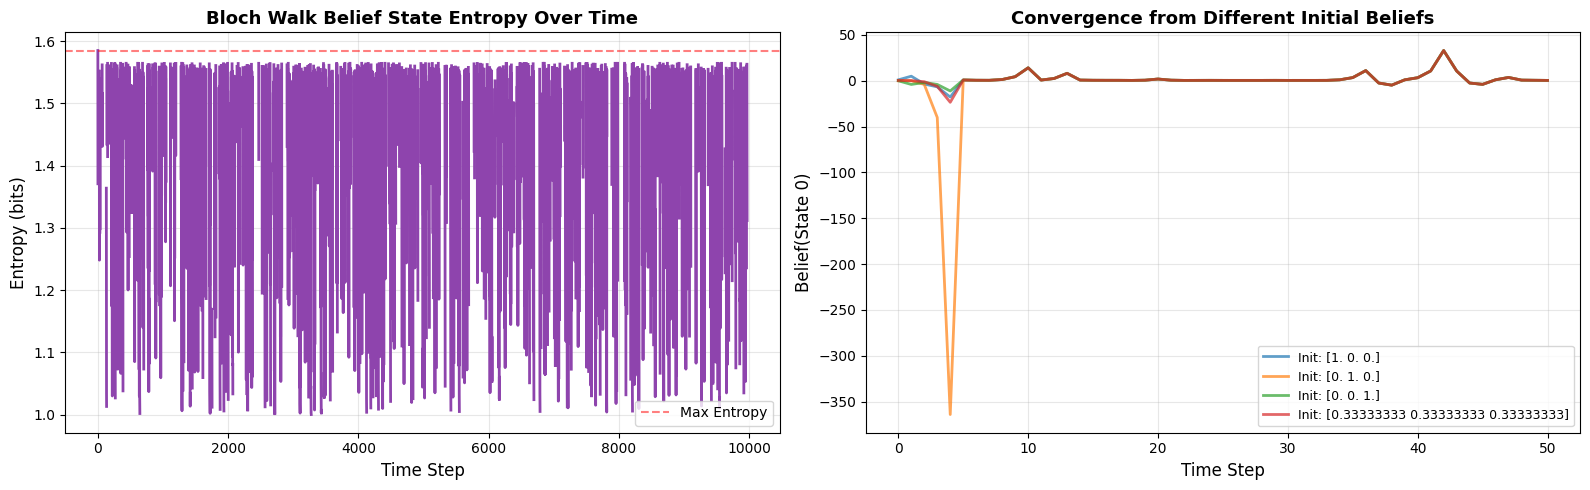

Belief analysis saved as 'bloch_walk_belief_analysis.png'

Entropy statistics:
  Initial entropy: 1.5850 bits
  Final entropy: nan bits
  Mean entropy: nan bits
  Max possible entropy: 1.5850 bits


In [17]:
def compute_entropy(belief_states):
    """Compute Shannon entropy of belief states."""
    eps = 1e-10
    return -np.sum(belief_states * np.log2(belief_states + eps), axis=1)


# Compute entropy over time
entropies = compute_entropy(beliefs)

# Test sensitivity to initial conditions
initial_conditions = [
    np.array([1.0, 0.0, 0.0]),  # Start in state 0
    np.array([0.0, 1.0, 0.0]),  # Start in state 1
    np.array([0.0, 0.0, 1.0]),  # Start in state 2
    np.array([1/3, 1/3, 1/3]),  # Uniform
]

beliefs_from_different_inits = []
for init in initial_conditions:
    b = compute_belief_states(T_bloch, emissions[:50], initial_belief=init)
    beliefs_from_different_inits.append(b)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Left: Entropy over time
ax1.plot(entropies, linewidth=2, color='#8e44ad')
ax1.set_xlabel('Time Step', fontsize=12)
ax1.set_ylabel('Entropy (bits)', fontsize=12)
ax1.set_title('Bloch Walk Belief State Entropy Over Time', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=np.log2(3), color='r', linestyle='--', alpha=0.5, label='Max Entropy')
ax1.legend(fontsize=10)

# Right: Convergence from different initial conditions
for i, (init, b) in enumerate(zip(initial_conditions, beliefs_from_different_inits)):
    label = f"Init: {init}"
    ax2.plot(b[:, 0], label=label, linewidth=2, alpha=0.7)

ax2.set_xlabel('Time Step', fontsize=12)
ax2.set_ylabel('Belief(State 0)', fontsize=12)
ax2.set_title('Convergence from Different Initial Beliefs', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9, loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bloch_walk_belief_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Belief analysis saved as 'bloch_walk_belief_analysis.png'")
print(f"\nEntropy statistics:")
print(f"  Initial entropy: {entropies[0]:.4f} bits")
print(f"  Final entropy: {entropies[-1]:.4f} bits")
print(f"  Mean entropy: {entropies.mean():.4f} bits")
print(f"  Max possible entropy: {np.log2(3):.4f} bits")

## 11. Summary

In [18]:
print("=" * 60)
print("BLOCH WALK (TomQA) PROCESS SUMMARY")
print("=" * 60)
print(f"\nParameters: alpha={alpha}, beta={beta}")
print(f"Derived parameter gamma: {gamma:.4f}")
print(f"\nTensor shape: {T_bloch.shape} [emission, from_state, to_state]")
print(f"Number of states: 3")
print(f"Number of emissions: 4")
print(f"\nNormalization check: {is_normalized}")
print(f"Contains negative values (quantum): {has_negative_values}")
print(f"\nMaximum transition value: {T_bloch.max():.4f}")
print(f"Minimum transition value: {T_bloch.min():.4f}")
print(f"\n--- Belief State Statistics ---")
print(f"Belief state dimensionality: {beliefs.shape[1]}")
print(f"Number of time steps computed: {len(beliefs)}")
print(f"Initial belief entropy: {entropies[0]:.4f} bits")
print(f"Final belief entropy: {entropies[-1]:.4f} bits")
print(f"Mean belief entropy: {entropies.mean():.4f} bits")
print(f"Max possible entropy: {np.log2(3):.4f} bits")
print("=" * 60)

BLOCH WALK (TomQA) PROCESS SUMMARY

Parameters: alpha=1.0, beta=0.5
Derived parameter gamma: 0.4472

Tensor shape: (4, 3, 3) [emission, from_state, to_state]
Number of states: 3
Number of emissions: 4

Normalization check: False
Contains negative values (quantum): True

Maximum transition value: 0.2500
Minimum transition value: -0.2000

--- Belief State Statistics ---
Belief state dimensionality: 3
Number of time steps computed: 10001
Initial belief entropy: 1.5850 bits
Final belief entropy: nan bits
Mean belief entropy: nan bits
Max possible entropy: 1.5850 bits
